This notebook implements a deep learning pipeline for Retinal OCT image classification. It covers data loading, preprocessing, model training with fine-tuning, evaluation, and saving/testing the trained model.

This cell imports the necessary libraries for the deep learning pipeline, including TensorFlow, Keras, NumPy, Matplotlib, and Seaborn.

In [ ]:
# ==========================================
# Retinal OCT Classification - Full Pipeline
# ==========================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import json
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

This cell downloads the Kermany2018 OCT dataset from KaggleHub, which is used for training the model.

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/kermany2018")

print("Path to dataset files:", path)

100%|██████████| 10.8G/10.8G [12:32<00:00, 15.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2


This cell defines key configuration parameters for the model, such as the dataset path, image size, batch size, and number of training epochs.

In [ ]:
# -----------------------------
# 1. Configuration
# -----------------------------
DATASET_PATH = "/root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 "  # Change if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
INITIAL_EPOCHS = 5
FINE_TUNE_EPOCHS = 5

print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))


GPUs Available: 1


This cell loads the dataset from the specified path, creating training, validation, and test datasets. It also extracts and prints the class names.

In [ ]:
# -----------------------------
# 2. Load Datasets
# -----------------------------
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)

# Save class mapping
with open("class_names.json", "w") as f:
    json.dump(class_names, f)



Found 83484 files belonging to 4 classes.
Found 32 files belonging to 4 classes.
Found 968 files belonging to 4 classes.
Classes: ['CNV', 'DME', 'DRUSEN', 'NORMAL']


This cell visualizes sample images from each class to ensure the datasets are loaded correctly and to get a visual understanding of the data.

### Visualize Sample Images
Let's display a few sample images from each class to ensure the datasets are loaded correctly.

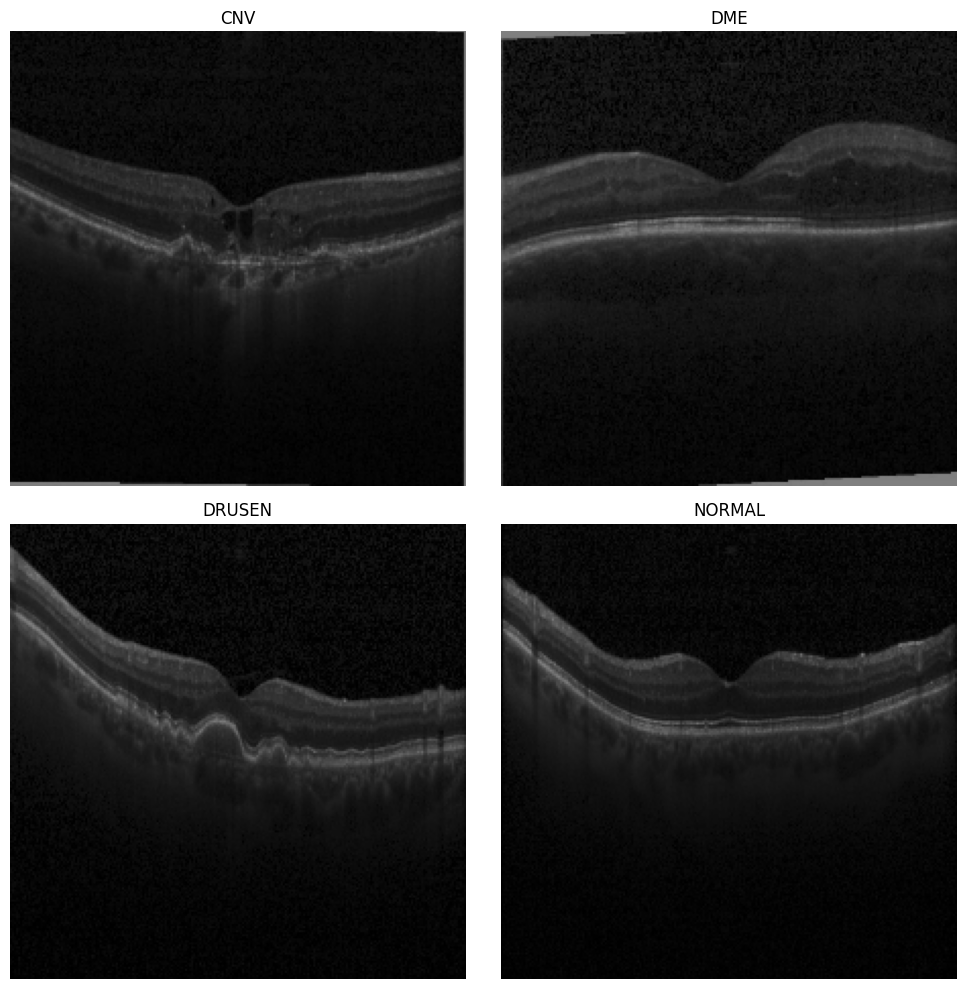

In [ ]:
plt.figure(figsize=(10, 10))
for i, class_name in enumerate(class_names):
    # Get a batch from the training dataset
    for images, labels in train_ds.take(1):
        # Filter images for the current class
        class_images = images[labels == i]
        if len(class_images) > 0:
            plt.subplot(num_classes // 2 + (num_classes % 2), 2, i + 1)
            # Take the first image of that class
            img_to_display = (class_images[0].numpy() * 0.5 + 0.5) if class_images[0].dtype == tf.float32 else class_images[0].numpy()
            plt.imshow(img_to_display.astype('uint8')) # Convert back to uint8 for display if float
            plt.title(class_name)
            plt.axis('off')
        else:
            # If no image found in the first batch, try to find one by iterating more (optional, for very sparse classes)
            pass
plt.tight_layout()
plt.show()

This section introduces the importance of checking class distribution.

### Class Distribution
It's important to check the distribution of classes in our training, validation, and test sets to identify any potential class imbalance.

This cell calculates and visualizes the class distribution across the training, validation, and test sets to identify any potential class imbalance.

--- Train set ---
Class CNV: 37205
Class DME: 11348
Class DRUSEN: 8616
Class NORMAL: 26315
--- Validation set ---
Class CNV: 8
Class DME: 8
Class DRUSEN: 8
Class NORMAL: 8
--- Test set ---
Class CNV: 242
Class DME: 242
Class DRUSEN: 242
Class NORMAL: 242


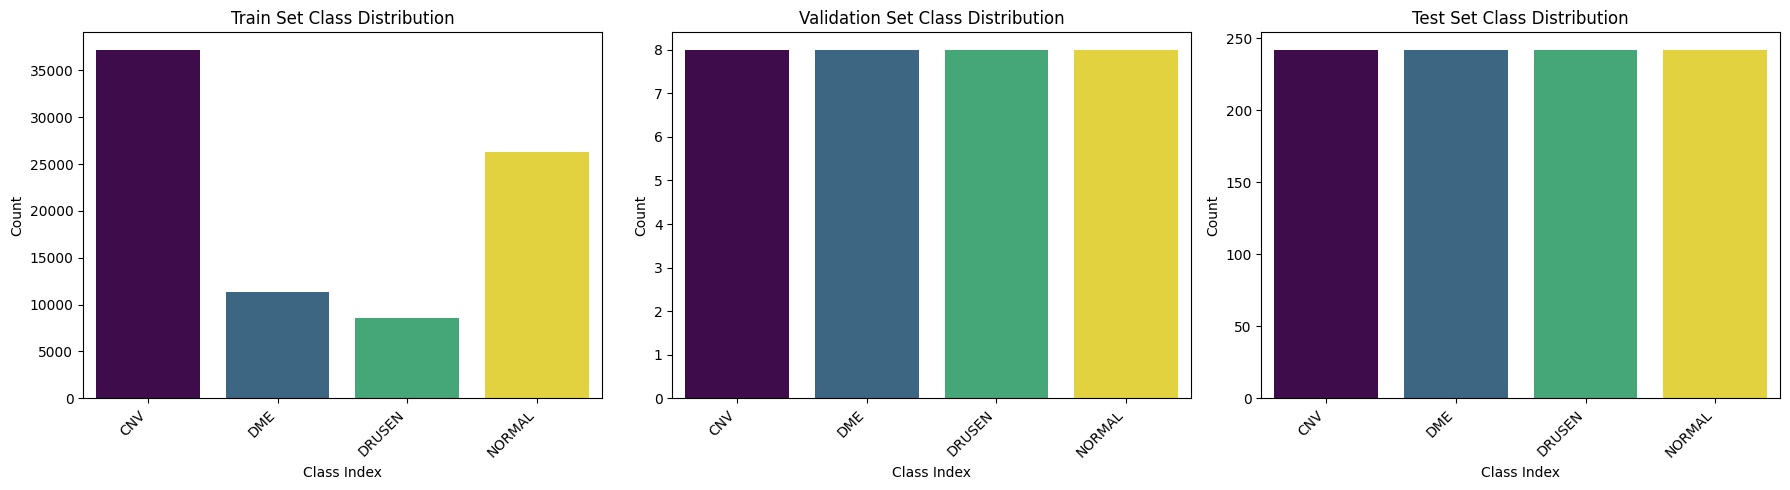

In [ ]:
def get_label_distribution(dataset, name):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy())
    unique_labels, counts = np.unique(labels, return_counts=True)
    print(f"--- {name} set ---")
    for label, count in zip(unique_labels, counts):
        print(f"Class {class_names[label]}: {count}")
    return labels

train_labels_dist = get_label_distribution(train_ds, "Train")
val_labels_dist = get_label_distribution(val_ds, "Validation")
test_labels_dist = get_label_distribution(test_ds, "Test")

# Plotting distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x=train_labels_dist, ax=axes[0], palette='viridis', hue=train_labels_dist, legend=False)
axes[0].set_title('Train Set Class Distribution')
axes[0].set_xlabel('Class Index')
axes[0].set_ylabel('Count')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')

sns.countplot(x=val_labels_dist, ax=axes[1], palette='viridis', hue=val_labels_dist, legend=False)
axes[1].set_title('Validation Set Class Distribution')
axes[1].set_xlabel('Class Index')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(class_names)))
axes[1].set_xticklabels(class_names, rotation=45, ha='right')

sns.countplot(x=test_labels_dist, ax=axes[2], palette='viridis', hue=test_labels_dist, legend=False)
axes[2].set_title('Test Set Class Distribution')
axes[2].set_xlabel('Class Index')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(len(class_names)))
axes[2].set_xticklabels(class_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

This cell defines the preprocessing function (ResNet50's preprocess_input) and applies it to all datasets. It also sets up `AUTOTUNE` for performance optimization.

In [ ]:
# -----------------------------
# 3. Preprocessing
# -----------------------------
preprocess = tf.keras.applications.resnet50.preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (preprocess(x), y)).prefetch(AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess(x), y)).prefetch(AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (preprocess(x), y)).prefetch(AUTOTUNE)


This section explains the purpose of data augmentation.

### Data Augmentation

Data augmentation is a technique used to increase the diversity of the training set by applying random transformations to the training images. This helps the model generalize better and reduces overfitting.

This cell defines a data augmentation pipeline with random horizontal flips, rotations, and zooms, and applies it to the training dataset.

In [ ]:
# 3.1 Data Augmentation

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

# Apply data augmentation only to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

This section introduces visualization of augmented images.

### Visualize Data Augmentation
Let's visualize some original images and their augmented versions to understand the transformations applied.

This cell displays several augmented images from the training set, allowing visualization of the applied transformations.

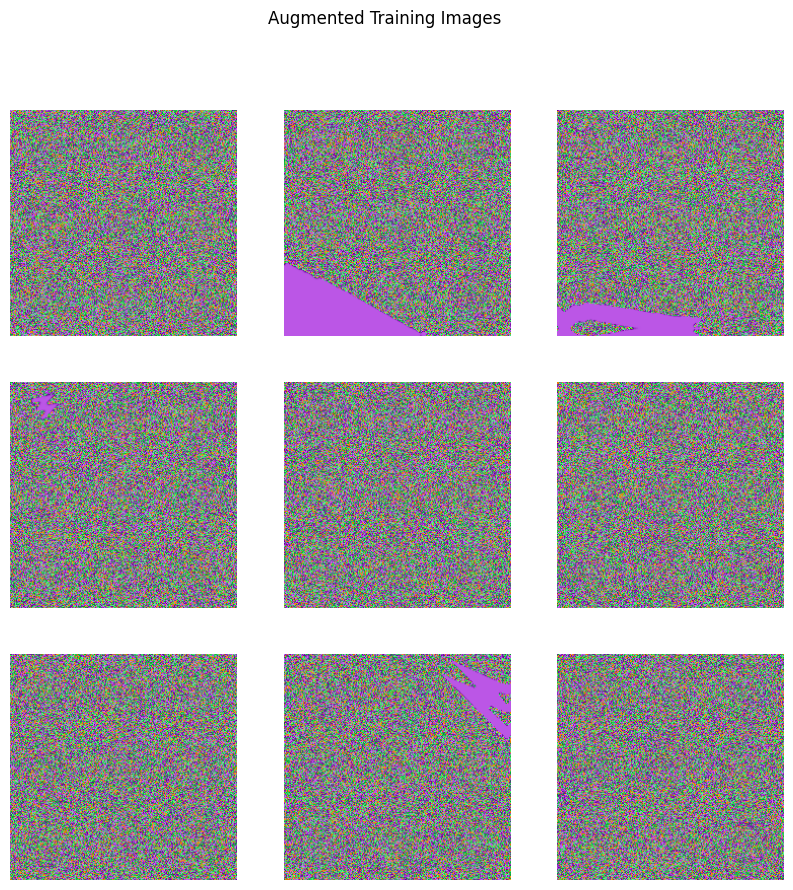

In [ ]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        # The 'images' from train_ds have already been preprocessed by ResNet50's preprocess_input
        # and then augmented by data_augmentation. Applying data_augmentation again here might lead
        # to unexpected results, but to fix the immediate ValueError due to input shape:
        # Add a batch dimension to the single image before passing it to data_augmentation.
        augmented_image_batch = data_augmentation(tf.expand_dims(images[i], axis=0))
        augmented_image = augmented_image_batch[0] # Extract the single augmented image

        plt.subplot(3, 3, i + 1)
        # ResNet50 preprocess_input normalizes to [-1, 1], so we need to convert back to [0, 255] for display
        # The augmented_image here is already in [-1, 1] range (or corrupted due to repeated augmentation on [-1, 1]).
        # The conversion (x * 0.5 + 0.5) * 255 attempts to bring it back to [0, 255].
        img_to_display = (augmented_image.numpy() * 0.5 + 0.5) * 255
        plt.imshow(img_to_display.astype('uint8'))
        plt.axis('off')
plt.suptitle('Augmented Training Images')
plt.show()

This cell computes class weights from the training labels to address potential class imbalance, ensuring the model doesn't get biased towards majority classes.

In [ ]:
# -----------------------------
# 4. Compute Class Weights
# -----------------------------
train_labels = []

for _, labels in train_ds:
    train_labels.extend(labels.numpy())

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(0.5609729875016799), 1: np.float64(1.8391787099048291), 2: np.float64(2.4223537604456826), 3: np.float64(0.7931217936538096)}


This cell defines the model architecture. It uses a pre-trained ResNet50 as the base model (initially frozen) and adds a global average pooling layer, a dropout layer, and a dense output layer for classification.

In [ ]:
# -----------------------------
# 5. Model Architecture
# -----------------------------
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # Phase 1 freeze

inputs = keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


This cell compiles the model for the initial training phase, setting the optimizer, loss function, and metrics.

In [ ]:
# -----------------------------
# 6. Compile (Phase 1)
# -----------------------------
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


This cell trains the frozen base model for a set number of initial epochs, using the computed class weights.

In [ ]:
# -----------------------------
# 7. Train Frozen Model
# -----------------------------
history_initial = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights_dict
)

Epoch 1/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1187s 448ms/step - accuracy: 0.6327 - loss: 0.9748 - val_accuracy: 0.9375 - val_loss: 0.2861
Epoch 2/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 999s 383ms/step - accuracy: 0.7420 - loss: 0.7159 - val_accuracy: 0.9375 - val_loss: 0.2526
Epoch 3/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 994s 381ms/step - accuracy: 0.7667 - loss: 0.6609 - val_accuracy: 0.9688 - val_loss: 0.1997
Epoch 4/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1001s 384ms/step - accuracy: 0.7784 - loss: 0.6302 - val_accuracy: 0.9688 - val_loss: 0.2058
Epoch 5/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 990s 379ms/step - accuracy: 0.7819 - loss: 0.6177 - val_accuracy: 0.9688 - val_loss: 0.2146


This cell initiates the fine-tuning phase by unfreezing a portion of the base model's layers and recompiling the model with a lower learning rate. It then continues training.

In [ ]:
# -----------------------------
# 8. Fine-Tuning Phase
# -----------------------------
base_model.trainable = True

# Freeze lower layers, unfreeze top block
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    class_weight=class_weights_dict
)

Epoch 1/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1070s 396ms/step - accuracy: 0.8525 - loss: 0.4314 - val_accuracy: 1.0000 - val_loss: 0.0332
Epoch 2/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1014s 388ms/step - accuracy: 0.8992 - loss: 0.3019 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 3/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1007s 386ms/step - accuracy: 0.9144 - loss: 0.2547 - val_accuracy: 1.0000 - val_loss: 0.0189
Epoch 4/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1052s 390ms/step - accuracy: 0.9254 - loss: 0.2246 - val_accuracy: 1.0000 - val_loss: 0.0163
Epoch 5/5
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 1040s 389ms/step - accuracy: 0.9307 - loss: 0.2047 - val_accuracy: 1.0000 - val_loss: 0.0142


This cell combines the training history from both initial training and fine-tuning, then plots the training and validation accuracy and loss over all epochs.

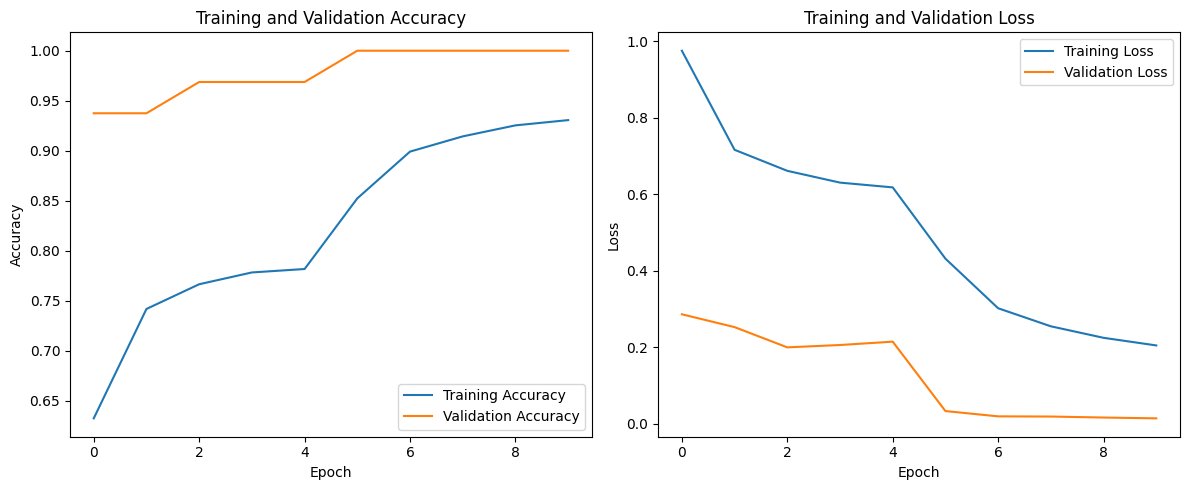

In [ ]:
history = history_initial.history
for k, v in history_fine.history.items():
    history[k].extend(v)

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

This cell evaluates the final trained model on the unseen test dataset and prints the overall test accuracy.

In [ ]:
# -----------------------------
# 9. Evaluate on TEST Set
# -----------------------------
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 261ms/step - accuracy: 0.9762 - loss: 0.0667
Test Accuracy: 0.9762396812438965


This cell calculates and displays detailed classification metrics (precision, recall, f1-score) and a confusion matrix for the test set, providing a comprehensive view of model performance per class.

              precision    recall  f1-score   support

         CNV       0.95      1.00      0.97       242
         DME       1.00      0.95      0.97       242
      DRUSEN       0.96      0.99      0.98       242
      NORMAL       0.99      0.97      0.98       242

    accuracy                           0.98       968
   macro avg       0.98      0.98      0.98       968
weighted avg       0.98      0.98      0.98       968



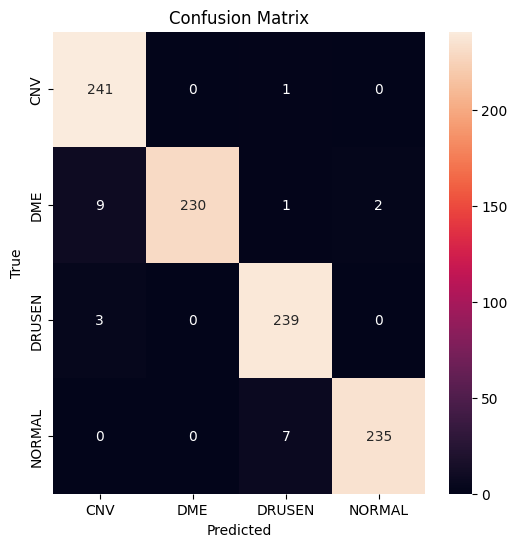

In [ ]:
# -----------------------------
# 10. Detailed Metrics
# -----------------------------
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


This cell saves the trained model in both the legacy HDF5 format (`.h5`) and the recommended Keras format (`.keras`), along with the class names.

In [ ]:
# -----------------------------
# 11. Save Model
# -----------------------------
# save model as ".hs"
model.save("retinal_model.h5")
print("Model saved as retinal_model.h5")

# Save as .keras (recommended modern format)
model.save("oct_retinal_model.keras")

print("Saved: oct_retinal_model.keras")




Model saved as retinal_model.h5
Saved: oct_retinal_model.keras


This cell loads the saved model and class names, then demonstrates how to use the model to predict the class of a single image, printing the predicted class and confidence.

In [ ]:
# -----------------------------
# 11. Test Model
# -----------------------------
import tensorflow as tf
import numpy as np
import json

# 1. Load the model and class names
model = tf.keras.models.load_model("oct_retinal_model.keras")

with open("class_names.json", "r") as f:
    class_names = json.load(f)

# 2. Load and preprocess the image
img_path = "/root/.cache/kagglehub/datasets/paultimothymooney/kermany2018/versions/2/OCT2017 /test/DME/DME-11053-1.jpeg"  # <-- Replace with your image path

img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create a batch of 1

# Apply the same ResNet50 preprocessing used during training
img_array = tf.keras.applications.resnet50.preprocess_input(img_array)

# 3. Predict
predictions = model.predict(img_array)
predicted_idx = np.argmax(predictions[0])
confidence = predictions[0][predicted_idx]

print(f"Predicted Class: {class_names[predicted_idx]}")
print(f"Confidence: {confidence:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted Class: DME
Confidence: 99.65%


This cell mounts Google Drive to allow saving and loading files directly to/from Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


This cell attempts to copy the saved model and class names to Google Drive for persistent storage.

In [ ]:
import shutil

shutil.copy("retinal_oct_model.keras",
            "/content/drive/MyDrive/oct_retinal_model.keras")

shutil.copy("class_names.json",
            "/content/drive/MyDrive/class_names.json")

print("Files copied to Google Drive.")

FileNotFoundError: [Errno 2] No such file or directory: 'oct_retinal_model.keras'

This cell lists the contents of the Google Drive root directory to verify if the files were copied or to check for existing files.

In [ ]:
import os
os.listdir("/content/drive/MyDrive/")

['References Islam',
 'Classroom',
 'Colab Notebooks',
 '.ipynb_checkpoints',
 'Ziarat Imam Ridha_copy.pdf',
 'Layla-and-Majnun-The-Classic-Love-Story-of-Persian-Literature_copy.pdf',
 '30-03-2026(19-2-38-721)_copy.PDF.pdf',
 'XAI-Retinal_Image.gsheet',
 'MV_OCT.ipynb',
 'Ibtaal F_copy.pdf',
 'Literature-Review.gsheet',
 'class_names.json',
 'oct_retinal_model.keras']

This cell downloads the saved `class_names.json` and `oct_retinal_model.keras` files to the local machine, making them available outside of Colab.

In [ ]:
from google.colab import files

files.download("class_names.json")
files.download("oct_retinal_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>